### Baseline: BiLSTM + Focal Loss

##### 1. Imports

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report
from sklearn.utils import class_weight
from collections import Counter

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score

##### 2. Configuration

In [2]:
class Config:
    MAX_WORDS = 20000
    MAX_LEN = 128
    EMBEDDING_DIM = 128
    HIDDEN_DIM = 64
    BATCH_SIZE = 64
    EPOCHS = 10
    LR = 1e-3
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    path = kagglehub.dataset_download("sandhyacvijay/beads-dataset")
    TRAIN_PATH = path + '/train_set.parquet'
    VAL_PATH = path + '/val_set.parquet'
    TEST_PATH = path + '/test_set.parquet'

100%|██████████| 252M/252M [00:01<00:00, 170MB/s]

Extracting files...


##### 3. Tokeniser

In [3]:
class SimpleTokenizer:
    def __init__(self, num_words):
        self.num_words = num_words
        self.word_index = {"<PAD>": 0, "<OOV>": 1}

    def fit_on_texts(self, texts):
        words = [word for text in texts for word in str(text).lower().split()]
        most_common = Counter(words).most_common(self.num_words - 2)
        for i, (word, _) in enumerate(most_common):
            self.word_index[word] = i + 2

    def texts_to_sequences(self, texts):
        sequences = []
        for text in texts:
            seq = [self.word_index.get(w, 1) for w in str(text).lower().split()]
            sequences.append(seq)
        return sequences

##### 4. Dataset Class

In [4]:
class MediaBiasDataset(Dataset):
    def __init__(self, sequences, labels_df):
        self.sequences = sequences
        self.bias = labels_df['bias'].values
        self.sentiment = labels_df['sentiment'].values
        self.toxic = labels_df['toxic'].values

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        # Manual padding to MAX_LEN
        seq = self.sequences[idx][:Config.MAX_LEN]
        padded_seq = seq + [0] * (Config.MAX_LEN - len(seq))

        return {
            'text': torch.tensor(padded_seq, dtype=torch.long),
            'bias': torch.tensor(self.bias[idx], dtype=torch.long),
            'sentiment': torch.tensor(self.sentiment[idx], dtype=torch.long),
            'toxic': torch.tensor(self.toxic[idx], dtype=torch.long)
        }

##### 5. Focal Loss

In [5]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # Calculate standard cross-entropy
        ce_loss = F.cross_entropy(logits, targets, reduction='none', weight=self.alpha)

        # Calculate probability of the correct class (pt)
        pt = torch.exp(-ce_loss)

        # Calculate focal component: (1-pt)^gamma
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()

##### 6. Model Architecture

In [6]:
class SpatialDropout(nn.Module):
    def __init__(self, drop_prob):
        super().__init__()
        self.drop = nn.Dropout1d(drop_prob)

    def forward(self, x):
        # Input x shape: [Batch, Seq_Len, Embedding_Dim]
        # Change to [Batch, Embedding_Dim, Seq_Len]
        x = x.permute(0, 2, 1)
        x = self.drop(x)
        # Change back to [Batch, Seq_Len, Embedding_Dim]
        return x.permute(0, 2, 1)

class MultitaskBiLSTM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, Config.EMBEDDING_DIM, padding_idx=0)
        self.spatial_dropout = SpatialDropout(0.2)
        self.lstm = nn.LSTM(Config.EMBEDDING_DIM, Config.HIDDEN_DIM,
                            bidirectional=True, batch_first=True)

        # Shared Dense Layer
        self.fc_shared = nn.Linear(Config.HIDDEN_DIM * 2, 64)
        self.relu = nn.ReLU()

        # Task Heads
        self.bias_head = nn.Linear(64, 3)
        self.sentiment_head = nn.Linear(64, 3)
        self.toxic_head = nn.Linear(64, 2)

    def forward(self, x):
        x = self.spatial_dropout(self.embedding(x))
        _, (h_n, _) = self.lstm(x)
        # Concatenate final forward and backward hidden states
        x = torch.cat((h_n[-2,:,:], h_n[-1,:,:]), dim=1)

        shared = self.relu(self.fc_shared(x))

        return {
            'bias': self.bias_head(shared),
            'sentiment': self.sentiment_head(shared),
            'toxic': self.toxic_head(shared)
        }

##### 7. Training Utilities

In [7]:
def get_weights(labels):
    weights = class_weight.compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    return torch.tensor(weights, dtype=torch.float).to(Config.DEVICE)

def get_focal_loss_functions(train_df, device):
    weights = {t: get_weights(train_df[t]) for t in ['bias', 'sentiment', 'toxic']}

    return {
        'bias': FocalLoss(alpha=weights['bias'], gamma=2.0),
        'sentiment': FocalLoss(alpha=weights['sentiment'], gamma=2.0),
        'toxic': FocalLoss(alpha=weights['toxic'], gamma=2.0)
    }

def train_one_epoch(model, loader, optimizer, loss_fns):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        text = batch['text'].to(Config.DEVICE)

        outputs = model(text)

        l_bias = loss_fns['bias'](outputs['bias'], batch['bias'].to(Config.DEVICE))
        l_sent = loss_fns['sentiment'](outputs['sentiment'], batch['sentiment'].to(Config.DEVICE))
        l_toxic = loss_fns['toxic'](outputs['toxic'], batch['toxic'].to(Config.DEVICE))

        loss = l_bias + l_sent + l_toxic
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

##### 8. Validation

In [8]:
def validate(model, loader, loss_fns):
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in loader:
            text = batch['text'].to(Config.DEVICE)
            outputs = model(text)

            l_bias = loss_fns['bias'](outputs['bias'], batch['bias'].to(Config.DEVICE))
            l_sent = loss_fns['sentiment'](outputs['sentiment'], batch['sentiment'].to(Config.DEVICE))
            l_toxic = loss_fns['toxic'](outputs['toxic'], batch['toxic'].to(Config.DEVICE))

            val_loss += (l_bias + l_sent + l_toxic).item()

    return val_loss / len(loader)

##### 9. Main Execution

In [9]:
if __name__ == "__main__":
    # Load Data
    train_df = pd.read_parquet(Config.TRAIN_PATH)
    val_df = pd.read_parquet(Config.VAL_PATH)

    # Tokenize
    tokenizer = SimpleTokenizer(Config.MAX_WORDS)
    tokenizer.fit_on_texts(train_df['text'])

    train_loader = DataLoader(MediaBiasDataset(tokenizer.texts_to_sequences(train_df['text']), train_df),
                              batch_size=Config.BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(MediaBiasDataset(tokenizer.texts_to_sequences(val_df['text']), val_df),
                            batch_size=Config.BATCH_SIZE)

    # Initialize Model & Weighted Losses
    model = MultitaskBiLSTM(Config.MAX_WORDS).to(Config.DEVICE)
    loss_fns = get_focal_loss_functions(train_df, Config.DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=Config.LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=2)

    # Training Loop
    best_val_loss = float('inf')

    for epoch in range(Config.EPOCHS):
        # 1. Train
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fns)

        # 2. Validate
        val_loss = validate(model, val_loader, loss_fns)

        # 3. Step Scheduler based on Validation Loss (Standard Research Practice)
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}/{Config.EPOCHS}")
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # 4. Checkpoint the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_bilstm_model.pt')
            print(f"--- New Best Model Saved (Val Loss: {best_val_loss:.4f}) ---")

Epoch 1/10
Train Loss: 0.5031 | Val Loss: 0.3807
--- New Best Model Saved (Val Loss: 0.3807) ---
Epoch 2/10
Train Loss: 0.3425 | Val Loss: 0.3663
--- New Best Model Saved (Val Loss: 0.3663) ---
Epoch 3/10
Train Loss: 0.3159 | Val Loss: 0.3561
--- New Best Model Saved (Val Loss: 0.3561) ---
Epoch 4/10
Train Loss: 0.3018 | Val Loss: 0.3470
--- New Best Model Saved (Val Loss: 0.3470) ---
Epoch 5/10
Train Loss: 0.2918 | Val Loss: 0.3485
Epoch 6/10
Train Loss: 0.2845 | Val Loss: 0.3503
Epoch 7/10
Train Loss: 0.2783 | Val Loss: 0.3486
Epoch 8/10
Train Loss: 0.2629 | Val Loss: 0.3436
--- New Best Model Saved (Val Loss: 0.3436) ---
Epoch 9/10
Train Loss: 0.2586 | Val Loss: 0.3504
Epoch 10/10
Train Loss: 0.2561 | Val Loss: 0.3468


##### 10. Evaluation

In [10]:
def run_evaluation():
    print("Loading Test Data...")
    test_df = pd.read_parquet(Config.TEST_PATH)

    tokenizer = SimpleTokenizer(Config.MAX_WORDS)
    # Ensure vocabulary matches training
    tokenizer.fit_on_texts(train_df['text'])

    test_loader = DataLoader(MediaBiasDataset(tokenizer.texts_to_sequences(test_df['text']), test_df),
                             batch_size=Config.BATCH_SIZE, shuffle=False)

    model = MultitaskBiLSTM(Config.MAX_WORDS).to(Config.DEVICE)
    model.load_state_dict(torch.load('best_bilstm_model.pt'))
    model.eval()

    all_preds = {'bias': [], 'sentiment': [], 'toxic': []}
    all_labels = {'bias': [], 'sentiment': [], 'toxic': []}

    with torch.no_grad():
        for batch in test_loader:
            text = batch['text'].to(Config.DEVICE)
            outputs = model(text)

            for task in ['bias', 'sentiment', 'toxic']:
                preds = torch.argmax(outputs[task], dim=1).cpu().numpy()
                all_preds[task].extend(preds)
                all_labels[task].extend(batch[task].numpy())

    for task in ['bias', 'sentiment', 'toxic']:
        print(f"\n{'='*20} {task.upper()} TASK {'='*20}")
        print(classification_report(all_labels[task], all_preds[task], digits=4))

    return all_labels, all_preds

labels, preds = run_evaluation()

Loading Test Data...

==================== BIAS TASK ====================
              precision    recall  f1-score   support

           0     0.9441    0.9674    0.9556    272957
           1     0.8735    0.8446    0.8588    137952
           2     0.9039    0.8792    0.8914     79011

    accuracy                         0.9186    489920
   macro avg     0.9072    0.8971    0.9019    489920
weighted avg     0.9178    0.9186    0.9180    489920


==================== SENTIMENT TASK ====================
              precision    recall  f1-score   support

           0     0.8877    0.9044    0.8960    157013
           1     0.8621    0.9278    0.8938    112854
           2     0.9523    0.9023    0.9267    220053

    accuracy                         0.9089    489920
   macro avg     0.9007    0.9115    0.9055    489920
weighted avg     0.9108    0.9089    0.9092    489920


==================== TOXIC TASK ====================
              precision    recall  f1-score   suppor

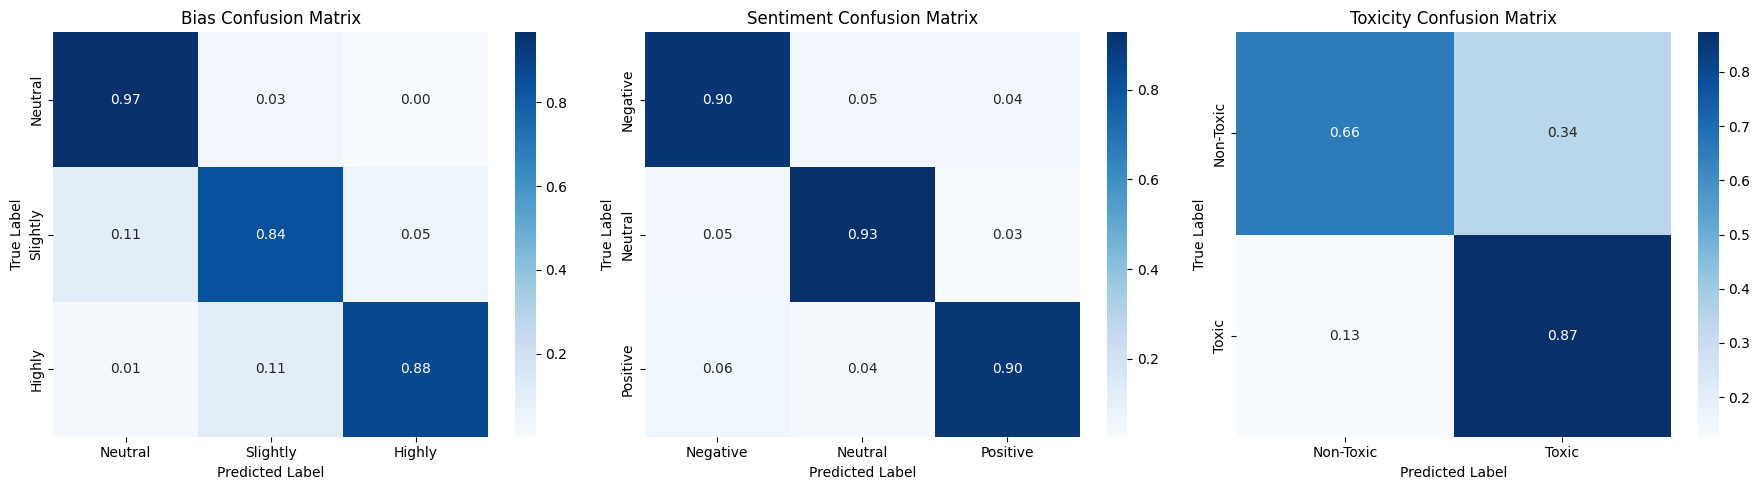

In [11]:
def plot_confusion_matrices(labels, preds):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    task_names = ['Bias', 'Sentiment', 'Toxicity']
    class_labels = {
        'bias': ['Neutral', 'Slightly', 'Highly'],
        'sentiment': ['Negative', 'Neutral', 'Positive'],
        'toxic': ['Non-Toxic', 'Toxic']
    }

    for i, task in enumerate(['bias', 'sentiment', 'toxic']):
        cm = confusion_matrix(labels[task], preds[task], normalize='true')
        sns.heatmap(cm, annot=True, fmt='.2f', ax=axes[i], cmap='Blues',
                    xticklabels=class_labels[task], yticklabels=class_labels[task])
        axes[i].set_title(f'{task_names[i]} Confusion Matrix')
        axes[i].set_ylabel('True Label')
        axes[i].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig('confusion_matrices.png')
    plt.show()

plot_confusion_matrices(labels, preds)

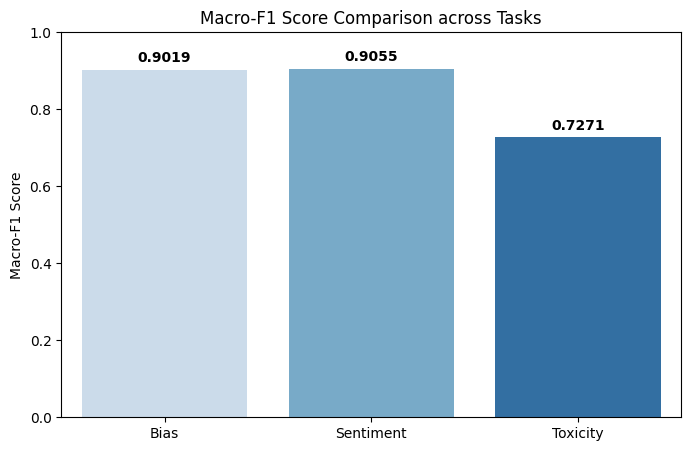

In [12]:
def plot_f1_comparison(labels, preds):
    tasks = ['bias', 'sentiment', 'toxic']
    f1_scores = [f1_score(labels[t], preds[t], average='macro') for t in tasks]

    plt.figure(figsize=(8, 5))

    sns.barplot(
        x=['Bias', 'Sentiment', 'Toxicity'],
        y=f1_scores,
        hue=['Bias', 'Sentiment', 'Toxicity'],
        palette='Blues',
        legend=False
    )

    plt.ylim(0, 1.0)
    plt.title('Macro-F1 Score Comparison across Tasks')
    plt.ylabel('Macro-F1 Score')
    for i, v in enumerate(f1_scores):
        plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

    plt.savefig('f1_comparison.png')
    plt.show()

plot_f1_comparison(labels, preds)